In [1]:
# Cell 1 — Imports, settings, and loading data/model

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import json
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Paths
processed_path = "../data/processed"
models_path    = "../models"

# Load datasets (with lifestyle features + cluster + Stress_Level)
train_df = pd.read_csv(os.path.join(processed_path, "train_with_clusters.csv"))
val_df   = pd.read_csv(os.path.join(processed_path, "val_with_clusters.csv"))
test_df  = pd.read_csv(os.path.join(processed_path, "test_with_clusters.csv"))

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

# Load trained model (Model B: lifestyle + cluster)
model_B = joblib.load(os.path.join(models_path, "multinomial_logreg_lifestyle_cluster.pkl"))

# Load feature config
with open(os.path.join(models_path, "model_config.json"), "r") as f:
    config = json.load(f)

features_B = config["features_model_B"]   # lifestyle + cluster
target_col = config["target"]
class_labels = config["classes"]

print("\nModel and config loaded.")
print("Features used by Model B:", features_B)
print("Target column:", target_col)
print("Class labels:", class_labels)


Train shape: (7868, 13)
Val shape:   (1681, 13)
Test shape:  (1686, 13)

Model and config loaded.
Features used by Model B: ['Sleep_Hours_Scaled', 'Work_Hours_Scaled', 'Physical_Activity_Hours_Scaled', 'Social_Media_Usage_Scaled', 'Diet_Quality_Encoded_Scaled', 'Smoking_Habit_Encoded_Scaled', 'Alcohol_Consumption_Encoded_Scaled', 'Cluster']
Target column: Stress_Level
Class labels: ['High', 'Low', 'Medium']


In [2]:
# Cell 2 — Prepare validation and test sets for evaluation

X_val  = val_df[features_B]
y_val  = val_df[target_col]

X_test = test_df[features_B]
y_test = test_df[target_col]

print("X_val shape: ", X_val.shape, " y_val:", y_val.shape)
print("X_test shape:", X_test.shape, " y_test:", y_test.shape)


X_val shape:  (1681, 8)  y_val: (1681,)
X_test shape: (1686, 8)  y_test: (1686,)


In [3]:
# Cell 3 — Accuracy and classification report for validation and test sets

# Validation predictions
val_pred = model_B.predict(X_val)
val_acc  = accuracy_score(y_val, val_pred)

print("===== MODEL B (Lifestyle + Cluster) — VALIDATION =====")
print("Validation Accuracy:", round(val_acc, 4))
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, digits=3))

# Test predictions
test_pred = model_B.predict(X_test)
test_acc  = accuracy_score(y_test, test_pred)

print("\n===== MODEL B (Lifestyle + Cluster) — TEST =====")
print("Test Accuracy:", round(test_acc, 4))
print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=3))


===== MODEL B (Lifestyle + Cluster) — VALIDATION =====
Validation Accuracy: 0.9334

Classification Report (Validation):
              precision    recall  f1-score   support

        High      0.958     0.957     0.957       806
         Low      0.950     0.953     0.952       443
      Medium      0.870     0.870     0.870       432

    accuracy                          0.933      1681
   macro avg      0.926     0.927     0.926      1681
weighted avg      0.933     0.933     0.933      1681


===== MODEL B (Lifestyle + Cluster) — TEST =====
Test Accuracy: 0.9437

Classification Report (Test):
              precision    recall  f1-score   support

        High      0.964     0.958     0.961       809
         Low      0.975     0.953     0.964       444
      Medium      0.877     0.908     0.892       433

    accuracy                          0.944      1686
   macro avg      0.939     0.939     0.939      1686
weighted avg      0.944     0.944     0.944      1686



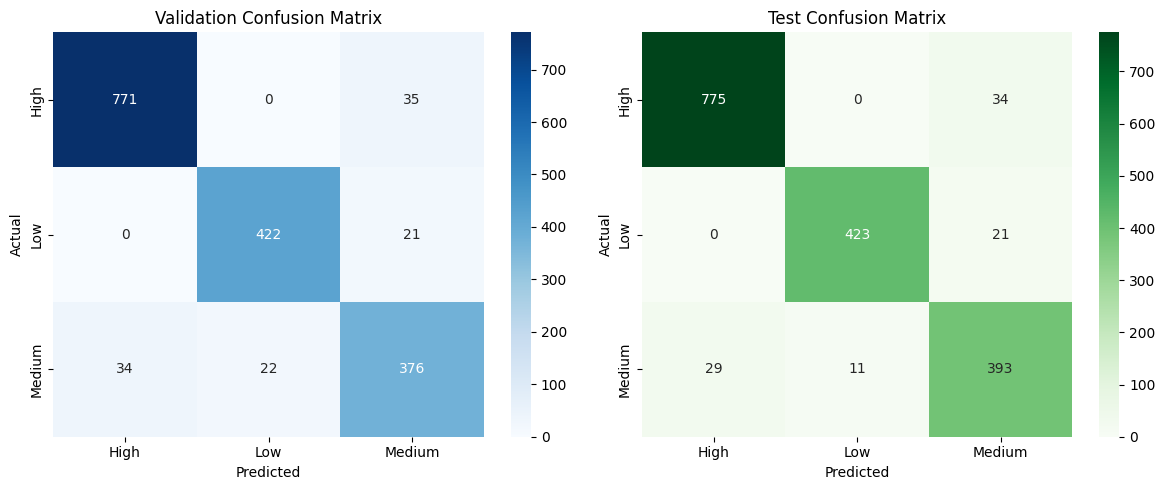

In [4]:
# Cell 4 — Confusion matrices for validation and test sets

# Ensure consistent class order
classes_sorted = sorted(list(set(list(y_test.unique()) + list(y_val.unique()))))

cm_val = confusion_matrix(y_val, val_pred, labels=classes_sorted)
cm_test = confusion_matrix(y_test, test_pred, labels=classes_sorted)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_sorted, yticklabels=classes_sorted, ax=axes[0])
axes[0].set_title("Validation Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes_sorted, yticklabels=classes_sorted, ax=axes[1])
axes[1].set_title("Test Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [5]:
# Cell 5 — Convert classification reports to DataFrames for nicer viewing / exporting

report_val_dict  = classification_report(y_val, val_pred, output_dict=True, digits=3)
report_test_dict = classification_report(y_test, test_pred, output_dict=True, digits=3)

report_val_df  = pd.DataFrame(report_val_dict).T
report_test_df = pd.DataFrame(report_test_dict).T

print("===== Validation Classification Report (DataFrame) =====")
display(report_val_df.round(3))

print("\n===== Test Classification Report (DataFrame) =====")
display(report_test_df.round(3))


===== Validation Classification Report (DataFrame) =====


,precision,recall,f1-score,support
High,0.958,0.957,0.957,806.000
Low,0.950,0.953,0.952,443.000
Medium,0.870,0.870,0.870,432.000
accuracy,0.933,0.933,0.933,0.933
macro avg,0.926,0.927,0.926,1681.000
weighted avg,0.933,0.933,0.933,1681.000



===== Test Classification Report (DataFrame) =====


,precision,recall,f1-score,support
High,0.964,0.958,0.961,809.000
Low,0.975,0.953,0.964,444.000
Medium,0.877,0.908,0.892,433.000
accuracy,0.944,0.944,0.944,0.944
macro avg,0.939,0.939,0.939,1686.000
weighted avg,0.944,0.944,0.944,1686.000


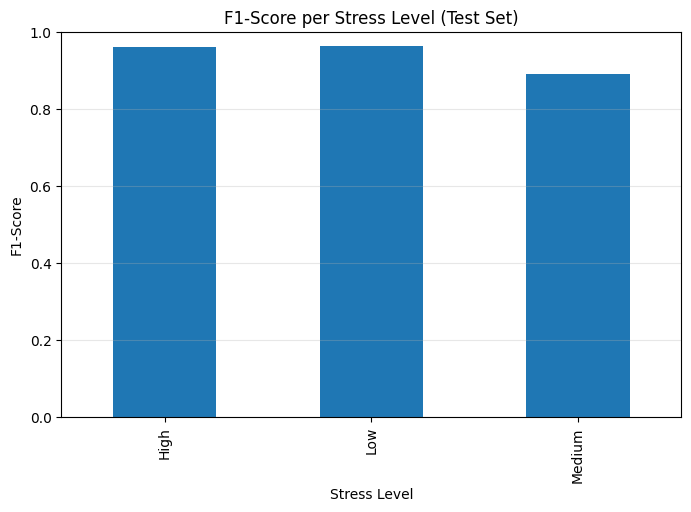

Per-class F1 scores (Test):


,precision,recall,f1-score
High,0.964,0.958,0.961
Low,0.975,0.953,0.964
Medium,0.877,0.908,0.892


In [6]:
# Cell 6 — F1-score per class for TEST set (bar plot)

# Filter out 'accuracy', 'macro avg', 'weighted avg'
per_class_test = report_test_df.loc[class_labels, ["precision", "recall", "f1-score"]]

plt.figure(figsize=(8, 5))
per_class_test["f1-score"].plot(kind="bar")
plt.title("F1-Score per Stress Level (Test Set)")
plt.ylabel("F1-Score")
plt.xlabel("Stress Level")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Per-class F1 scores (Test):")
display(per_class_test.round(3))


In [7]:
# Cell 7 — Text summary of evaluation (for thesis write-up)

summary_text = f"""
Final Evaluation Summary (Model B — Lifestyle + Cluster):

• Validation Accuracy: {val_acc:.3f}
• Test Accuracy:       {test_acc:.3f}

Per-class performance on the TEST set:
"""

print(summary_text)
print(per_class_test.round(3))



Final Evaluation Summary (Model B — Lifestyle + Cluster):

• Validation Accuracy: 0.933
• Test Accuracy:       0.944

Per-class performance on the TEST set:

        precision  recall  f1-score
High        0.964   0.958     0.961
Low         0.975   0.953     0.964
Medium      0.877   0.908     0.892
